In [28]:
#Imports:
import torch
from torch.nn import functional as F
import matplotlib.pyplot as plt
import random


In [29]:
# Making A Deeper Model Network:

class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weights=torch.randn((fan_in,fan_out),generator=g)/fan_in**0.5
        self.bias=torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out=x @ self.weights
        if self.bias is not None:
            self.out+=self.bias
        return self.out

    def parameters(self):
        return [self.weights]+ ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps=eps
        self.momentum=momentum
        self.training=True
        #Parameters to learn:
        self.gamma=torch.ones(dim) 
        self.beta=torch.zeros(dim) 
        #Buffers(not parameters, but part of the state of the module that will be used in inference mode):
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)

    def __call__(self,x):
        if self.training:
            xmean=x.mean(0,keepdim=True)
            xvar=x.var(0,keepdim=True)
        else:
            xmean=self.running_mean
            xvar=self.running_var
        xhat=(x-xmean)/(torch.sqrt(xvar+self.eps))
        self.out=self.gamma*xhat+self.beta
        #update the buffers:
        if self.training:
            with torch.no_grad():
                self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean
                self.running_var=(1-self.momentum)*self.running_var+self.momentum*xvar
            return self.out

    def parameters(self):
        return [self.gamma,self.beta]
    
class tanh:
    def __call__(self,x):
        self.out=torch.tanh(x)
        return self.out

    def parameters(self):
        return []

n_embed=10
n_hidden=100
block_size=3
vocab_size=27
g=torch.Generator().manual_seed(2147483647)

# Model  parameters:
model=torch.randn((vocab_size,n_embed),generator=g)
layers=[
    Linear(n_embed*block_size,n_hidden),
    BatchNorm1d(n_hidden),
    tanh(),
    Linear(n_hidden,n_hidden),
    BatchNorm1d(n_hidden),
    tanh(),
    Linear(n_hidden,n_hidden),
    BatchNorm1d(n_hidden),
    tanh(),
    Linear(n_hidden,n_hidden),
    BatchNorm1d(n_hidden),
    tanh(),
    Linear(n_hidden,n_hidden),
    BatchNorm1d(n_hidden),
    tanh(),
    Linear(n_hidden,vocab_size),
    BatchNorm1d(vocab_size),
]

# 1 / sqrt(fan_in) keeps the linear layer stable.
# It prevents the dot product from exploding just because there are many inputs.
# But after that, you apply tanh, which is also a squashing function.
# Tanh compresses values toward −1 and 1, which slightly reduces variance.
# Now when you stack many layers:

# Linear (stable) → tanh (shrinks a bit)
# Linear (stable) → tanh (shrinks a bit)
# …
# That “shrinks a bit” compounds across layers.
# So the signal slowly gets smaller and gradients weaken.
# The 5/3 factor is just a correction for tanh’s shrinking effect.

with torch.no_grad():
    #Making the last layer less sensitive to the initial random weights:
    layers[-1].gamma*=0.1
    #Applying Gain Scaling to the other layers:
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weights*=5/3

parameters=[model]+ [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

47551


In [30]:
# DataSet:
words=open('names.txt','r').read().splitlines()
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}

def build_dataset(words):
    block_size=3
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y


# Creating Training , Validation and Test sets
random.seed(42)
random.shuffle(words)

n1=int(len(words)*0.8)
n2=int(len(words)*0.9)
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

      0/200000 : 3.2870
  10000/200000 : 2.3578
  20000/200000 : 2.1042
  30000/200000 : 1.9646
  40000/200000 : 2.2144
  50000/200000 : 2.2264
  60000/200000 : 1.7339
  70000/200000 : 2.1746
  80000/200000 : 2.1895
  90000/200000 : 1.8282
 100000/200000 : 2.3641
 110000/200000 : 2.2021
 120000/200000 : 2.1036
 130000/200000 : 1.8565
 140000/200000 : 1.8050
 150000/200000 : 1.9258
 160000/200000 : 1.8759
 170000/200000 : 1.8332
 180000/200000 : 2.2319
 190000/200000 : 2.0518


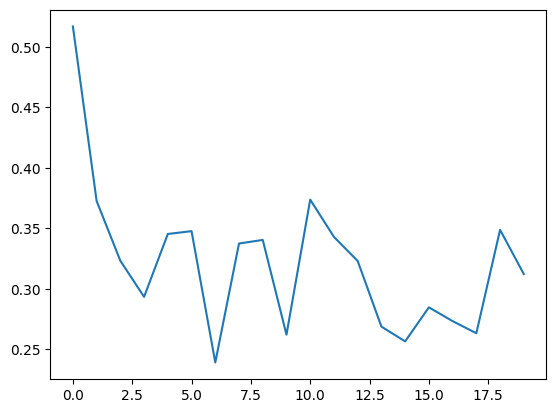

In [31]:
#Training Block:

epochs=200000
batch_size=32
losses=[]

for epoch in range(epochs):
    #Minibatch construct:
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb, Yb=Xtr[ix],Ytr[ix]

    # Do the Forward pass:
    emb=model[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)

    #Calulate the loss:
    loss=F.cross_entropy(x,Yb)

    #Backward pass:
    for layer in layers:
        layer.out.retain_grad() # retain the gradients for each layer's output for backpropagation
    # Optimizer Zero_grad:
    for p in parameters:
        p.grad=None
    # Loss Backward:
    loss.backward()

    #Updating the parameters:
    #optimizer step-step:
    lr=0.1 if epoch<100000 else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    #Track the loss:
    if epoch%10000==0:
        print(f'{epoch:7d}/{epochs} : {loss.item():.4f}')
        losses.append(loss.log10().item())
#Plot the losses:
plt.plot(losses)

    
